In [24]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [25]:
# List your experiments here
# experiments = [
#     {"id": "exp_20250625_014444", "name": "Openwhisk"},
#     {"id": "exp_20250625_071954", "name": "Proposed"},
#     {"id": "exp_20250624_210136", "name": "Histogram"},
#     {"id": "exp_20250624_165438", "name": "Pagurus"},
# ]
experiments = [
    {"id": "exp_20250627_145610", "name": "Openwhisk"},
    {"id": "exp_20250627_103341", "name": "NMIG"},
    {"id": "exp_20250627_213220", "name": "Histogram"},
    {"id": "exp_20250628_065241", "name": "Pagurus"},
]

In [26]:
# import pandas as pd
# import json

def parse_json_safe(val):
    if pd.isna(val) or val == "None":
        return None
    if isinstance(val, dict):  # Already a dict
        return val
    try:
        return json.loads(val)
    except Exception:
        return None

def extract_name(res,name):
    if isinstance(res, dict):
        return res.get(name)
    return None




def extract_error_message(res):
    if isinstance(res, dict):
        resp = res.get("response", {})
        if not resp.get("success", True):
            return resp.get("result", {}).get("error")
    return None

def has_cuda_error(msg):
    if isinstance(msg, str):
        return "cuda" in msg.lower() or "cudnn" in msg.lower()
    return False

def extract_success(res):
    if isinstance(res, dict):
        return res.get("response", {}).get("success", True)
    return False



In [27]:
# plt.figure(figsize=(4, 3.5))
results = {}
df_res = {}

def pick_particular_column(rp,col="initTime"):
    # rp is expected to be a dict with key 'annotations' that is a list of dicts
    if not isinstance(rp, dict):
        return 0
    items = rp.get("annotations", []) or []
    for it in items:
        if isinstance(it, dict) and it.get("key") == col:
            return (it.get("value", 0))/1000
    return 0

    
for exp in experiments:
    # load the CSV for this experiment
    path = f"../results/{exp['id']}/results_updated.csv"
    df = pd.read_csv(path)

    # parse JSON and compute latency
    df["result_parsed"] = df["result"].apply(parse_json_safe)
    df["name"] = df["result_parsed"].apply(lambda res: extract_name(res, "name"))
    df['name'] = df['name'].str.replace(r'_p$', '', regex=True)
    df["start"] = df["result_parsed"].apply(lambda res: extract_name(res, "start"))
    df["end"] = df["result_parsed"].apply(lambda res: extract_name(res, "end"))
    df['latency'] = (df['end'] - df['start'])/1000
    df["error_message"] = df["result_parsed"].apply(extract_error_message)
    df["has_cuda_or_cudnn_error"] = df["error_message"].apply(has_cuda_error)
    df["success"] = df["result_parsed"].apply(extract_success)
    df["error"] = df["result_parsed"].isna() | (~df["success"])
    df["initTime"] = df["result_parsed"].apply(lambda x: pick_particular_column(x, col="initTime"))
    df["waitTime"] = df["result_parsed"].apply(lambda x: pick_particular_column(x, col="waitTime"))
    

    df_res[exp['name']] = df
    # error_counts = df['error'].value_counts()
    # results[exp['name']] = {}
    # results[exp['name']]['true_val'] = error_counts.get(True, 0)
    # results[exp['name']]['false_val'] = error_counts.get(False, 0)
    # results[exp['name']]['false_val'] = df['latency'].mean()
    # df_valid = df[df["error"] != True]
    # avg_latency_per_name_dict = df_valid.groupby("name")["latency"].mean().to_dict()
    # print(avg_latency_per_name_dict)
    # df_res[exp['
    print(exp)
    
   
    # df = df[df['latency'] < 300]

print(results)

{'id': 'exp_20250627_145610', 'name': 'Openwhisk'}
{'id': 'exp_20250627_103341', 'name': 'NMIG'}
{'id': 'exp_20250627_213220', 'name': 'Histogram'}
{'id': 'exp_20250628_065241', 'name': 'Pagurus'}
{}


In [28]:
# for l in experiments:
# count_zero = (df_res['Openwhisk']["initTime"] == 0).sum()

for l in df_res:
    count_zero_initTime = (df_res[l]["initTime"] == 0).sum()
    print(f"{l} - {count_zero_initTime}")
print(20*"*")
for l in df_res:
    count_zero_initTime = (df_res[l]["waitTime"] == 0).sum()
    print(f"{l} - {count_zero_initTime}")

Openwhisk - 734
NMIG - 660
Histogram - 650
Pagurus - 733
********************
Openwhisk - 0
NMIG - 0
Histogram - 0
Pagurus - 0


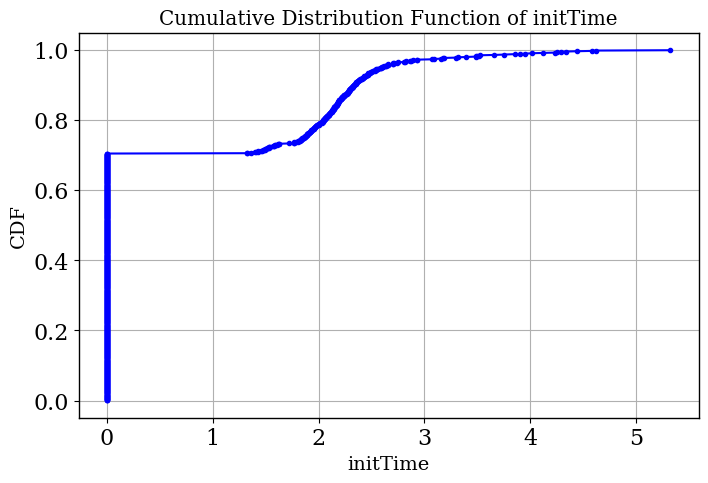

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Drop missing values and sort
data = df_res['Openwhisk']["initTime"].dropna().sort_values().values

# Compute the CDF
cdf = np.arange(1, len(data) + 1) / len(data)

# Plot the CDF
plt.figure(figsize=(8, 5))
plt.plot(data, cdf, marker='.', linestyle='-', color='blue')
plt.xlabel("initTime")
plt.ylabel("CDF")
plt.title("Cumulative Distribution Function of initTime")
plt.grid(True)
plt.show()


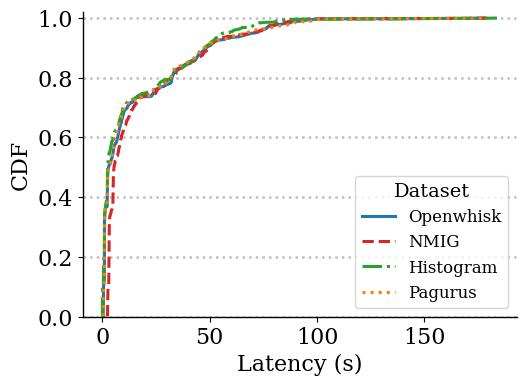

In [32]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.0,
})

def ecdf(values):
    v = np.asarray(values)
    v = v[~np.isnan(v)]
    v.sort()
    if v.size == 0:
        return v, v
    y = np.arange(1, v.size + 1) / v.size
    return v, y

column = "latency"
drop_zeros = False
use_log_x = False

# Larger figure for better visibility
fig, ax = plt.subplots(figsize=(5.2, 3.8))

# IEEE-safe color palette
colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

all_vals = []

for i, (name, df) in enumerate(df_res.items()):
    if column not in df.columns:
        continue

    s = df[column]
    s = s.apply(lambda x: np.nan if isinstance(x, str) else x).astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if drop_zeros:
        s = s[s != 0]

    x, y = ecdf(s.values)
    if x.size == 0:
        continue

    all_vals.append(x)
    ax.plot(
        x, y,
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.2,                # thicker lines
        label=name
    )

ax.set_xlabel(f"Latency (s)",fontsize=16)
ax.set_ylabel("CDF",fontsize=16)

# if len(all_vals) > 0:
#     merged = np.concatenate(all_vals)
#     xmin, xmax = merged.min(), merged.max()
#     ax.set_xlim(xmin - 2, xmax * 1.05)

# Zoom in vertically to highlight curve shape
ax.set_ylim(0.0, 1.02)

# IEEE clean layout
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=1.8, alpha=0.8)
ax.legend(loc="lower right", frameon=True, title="Dataset",fontsize=12,title_fontsize=14)

if use_log_x:
    ax.set_xscale("log")

fig.tight_layout(pad=0.4)

# Optional: save high-resolution output
# fig.savefig("latency_cdf_ieee_zoomed.pdf", bbox_inches="tight")
fig.savefig("latency_cdf_paper.png", dpi=300, bbox_inches="tight")

plt.show()


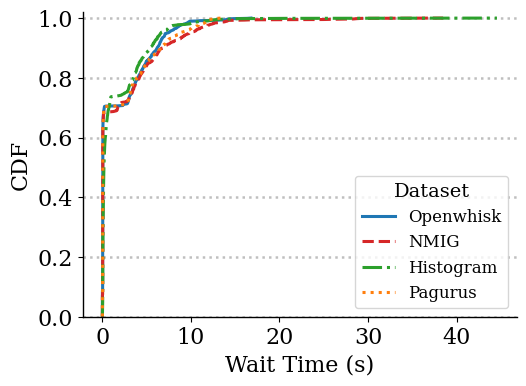

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.0,
})

def ecdf(values):
    v = np.asarray(values)
    v = v[~np.isnan(v)]
    v.sort()
    if v.size == 0:
        return v, v
    y = np.arange(1, v.size + 1) / v.size
    return v, y

column = "waitTime"
drop_zeros = False
use_log_x = False

# Larger figure for better visibility
fig, ax = plt.subplots(figsize=(5.2, 3.8))

# IEEE-safe color palette
colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

all_vals = []

for i, (name, df) in enumerate(df_res.items()):
    if column not in df.columns:
        continue

    s = df[column]
    s = s.apply(lambda x: np.nan if isinstance(x, str) else x).astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if drop_zeros:
        s = s[s != 0]

    x, y = ecdf(s.values)
    if x.size == 0:
        continue

    all_vals.append(x)
    ax.plot(
        x, y,
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.2,                # thicker lines
        label=name
    )

ax.set_xlabel(f"Wait Time (s)",fontsize=16)
ax.set_ylabel("CDF",fontsize=16)

# if len(all_vals) > 0:
#     merged = np.concatenate(all_vals)
#     xmin, xmax = merged.min(), merged.max()
#     ax.set_xlim(xmin - 2, xmax * 1.05)

# Zoom in vertically to highlight curve shape
ax.set_ylim(0.0, 1.02)

# IEEE clean layout
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=1.8, alpha=0.8)
ax.legend(loc="lower right", frameon=True, title="Dataset",fontsize=12,title_fontsize=14)

if use_log_x:
    ax.set_xscale("log")

fig.tight_layout(pad=0.4)

# Optional: save high-resolution output
# fig.savefig("latency_cdf_ieee_zoomed.pdf", bbox_inches="tight")
fig.savefig("wait_time_cdf_paper.png", dpi=300, bbox_inches="tight")

plt.show()

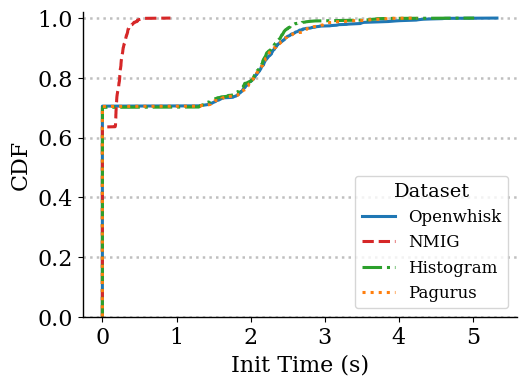

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.0,
})

def ecdf(values):
    v = np.asarray(values)
    v = v[~np.isnan(v)]
    v.sort()
    if v.size == 0:
        return v, v
    y = np.arange(1, v.size + 1) / v.size
    return v, y

column = "initTime"
drop_zeros = False
use_log_x = False

# Larger figure for better visibility
fig, ax = plt.subplots(figsize=(5.2, 3.8))

# IEEE-safe color palette
colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

all_vals = []

for i, (name, df) in enumerate(df_res.items()):
    if column not in df.columns:
        continue

    s = df[column]
    s = s.apply(lambda x: np.nan if isinstance(x, str) else x).astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if drop_zeros:
        s = s[s != 0]

    x, y = ecdf(s.values)
    if x.size == 0:
        continue

    all_vals.append(x)
    ax.plot(
        x, y,
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.2,                # thicker lines
        label=name
    )

ax.set_xlabel(f"Init Time (s)",fontsize=16)
ax.set_ylabel("CDF",fontsize=16)

# if len(all_vals) > 0:
#     merged = np.concatenate(all_vals)
#     xmin, xmax = merged.min(), merged.max()
#     ax.set_xlim(xmin - 2, xmax * 1.05)

# Zoom in vertically to highlight curve shape
ax.set_ylim(0.0, 1.02)

# IEEE clean layout
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=1.8, alpha=0.8)
ax.legend(loc="lower right", frameon=True, title="Dataset",fontsize=12,title_fontsize=14)

if use_log_x:
    ax.set_xscale("log")

fig.tight_layout(pad=0.4)

# Optional: save high-resolution output
# fig.savefig("latency_cdf_ieee_zoomed.pdf", bbox_inches="tight")
fig.savefig("init_time_cdf_paper_proposed.png", dpi=300, bbox_inches="tight")

plt.show()


In [98]:
# import numpy as np
# import matplotlib.pyplot as plt

# plt.rcParams.update({
#     "font.family": "serif",
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
#     "axes.labelsize": 10,  # Adjusted to IEEE guideline (8-10 pt)
#     "font.size": 10,       # Adjusted to IEEE guideline
#     "legend.fontsize": 9,  # Adjusted to IEEE guideline (9-12 pt)
#     "xtick.labelsize": 8,  # Adjusted to IEEE guideline (8-10 pt)
#     "ytick.labelsize": 8,  # Adjusted to IEEE guideline (8-10 pt)
#     "axes.linewidth": 0.8, # Adjusted to IEEE guideline
# })

# def ecdf(values):
#     v = np.asarray(values)
#     v = v[~np.isnan(v)]
#     v.sort()
#     if v.size == 0:
#         return v, v
#     y = np.arange(1, v.size + 1) / v.size
#     return v, y

# column = "latency"
# drop_zeros = False
# use_log_x = False

# # Larger figure for better visibility, adjusted for IEEE proportions
# fig, ax = plt.subplots(figsize=(5.2, 3.8))

# # IEEE-safe color palette with distinct grayscale patterns
# colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
# linestyles = ["-", "--", "-.", ":", "-"]  # Simplified for clarity

# all_vals = []

# for i, (name, df) in enumerate(df_res.items()):
#     if column not in df.columns:
#         continue

#     s = df[column]
#     s = s.apply(lambda x: np.nan if isinstance(x, str) else x).astype(float)
#     s = s.replace([np.inf, -np.inf], np.nan).dropna()
#     if drop_zeros:
#         s = s[s != 0]

#     x, y = ecdf(s.values)
#     if x.size == 0:
#         continue

#     all_vals.append(x)
#     ax.plot(
#         x, y,
#         color=colors[i % len(colors)],
#         linestyle=linestyles[i % len(linestyles)],
#         linewidth=1.0,  # Adjusted for IEEE thin lines
#         label=name
#     )

# ax.set_xlabel("Latency (s)")
# ax.set_ylabel("CDF")

# if len(all_vals) > 0:
#     merged = np.concatenate(all_vals)
#     xmin, xmax = merged.min(), merged.max()
#     ax.set_xlim(xmin - 2 if xmin > 0 else 0, xmax * 1.05)

# # Zoom in vertically to highlight curve shape
# ax.set_ylim(0.0, 1.02)

# # IEEE clean layout
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.6)  # Adjusted for subtlety
# ax.legend(loc="lower right", frameon=False, title="Dataset")

# if use_log_x:
#     ax.set_xscale("log")

# fig.tight_layout(pad=0.2)  # Reduced padding for compactness

# # Save high-resolution output for IEEE submission
# # fig.savefig("latency_cdf_ieee.pdf", bbox_inches="tight", dpi=600)
# # fig.savefig("latency_cdf_ieee.png", dpi=600, bbox_inches="tight")

# plt.show()

NameError: name 'df_res' is not defined

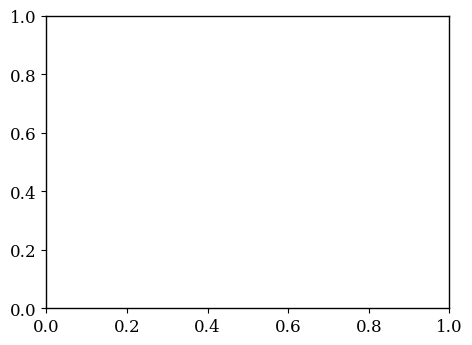

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
})

def ecdf(values):
    v = np.asarray(values)
    v = v[~np.isnan(v)]
    v.sort()
    if v.size == 0:
        return v, v
    y = np.arange(1, v.size + 1) / v.size
    return v, y

column = "initTime"
drop_zeros = False
use_log_x = False

# Larger figure for better visibility
fig, ax = plt.subplots(figsize=(5.2, 3.8))

# IEEE-safe color palette
colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

all_vals = []

for i, (name, df) in enumerate(df_res.items()):
    if column not in df.columns:
        continue

    s = df[column]
    s = s.apply(lambda x: np.nan if isinstance(x, str) else x).astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if drop_zeros:
        s = s[s != 0]

    x, y = ecdf(s.values)
    if x.size == 0:
        continue

    all_vals.append(x)
    ax.plot(
        x, y,
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.2,                # thicker lines
        label=name
    )

ax.set_xlabel(f"Latency (s)")
ax.set_ylabel("CDF")

# if len(all_vals) > 0:
#     merged = np.concatenate(all_vals)
#     xmin, xmax = merged.min(), merged.max()
#     ax.set_xlim(xmin - 2, xmax * 1.05)

# Zoom in vertically to highlight curve shape
# ax.set_ylim(0.0, 1.02)

# IEEE clean layout
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=1.8, alpha=0.8)
ax.legend(loc="lower right", frameon=False, title="Dataset")

if use_log_x:
    ax.set_xscale("log")

fig.tight_layout(pad=0.4)

# Optional: save high-resolution output
# fig.savefig("latency_cdf_ieee_zoomed.pdf", bbox_inches="tight")
# fig.savefig("latency_cdf_ieee_zoomed.png", dpi=600, bbox_inches="tight")

plt.show()


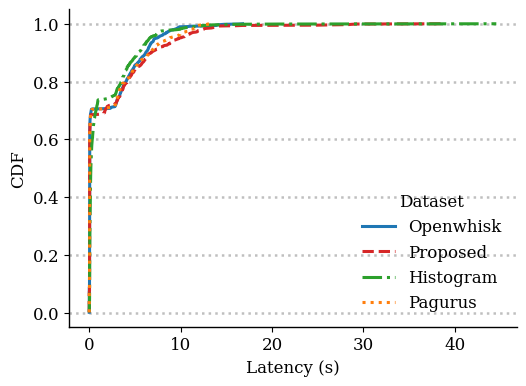

In [100]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
})

def ecdf(values):
    v = np.asarray(values)
    v = v[~np.isnan(v)]
    v.sort()
    if v.size == 0:
        return v, v
    y = np.arange(1, v.size + 1) / v.size
    return v, y

column = "waitTime"
drop_zeros = False
use_log_x = False

# Larger figure for better visibility
fig, ax = plt.subplots(figsize=(5.2, 3.8))

# IEEE-safe color palette
colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

all_vals = []

for i, (name, df) in enumerate(df_res.items()):
    if column not in df.columns:
        continue

    s = df[column]
    s = s.apply(lambda x: np.nan if isinstance(x, str) else x).astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if drop_zeros:
        s = s[s != 0]

    x, y = ecdf(s.values)
    if x.size == 0:
        continue

    all_vals.append(x)
    ax.plot(
        x, y,
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.2,                # thicker lines
        label=name
    )

ax.set_xlabel(f"Latency (s)")
ax.set_ylabel("CDF")

# if len(all_vals) > 0:
#     merged = np.concatenate(all_vals)
#     xmin, xmax = merged.min(), merged.max()
#     ax.set_xlim(xmin - 2, xmax * 1.05)

# Zoom in vertically to highlight curve shape
# ax.set_ylim(0.0, 1.02)

# IEEE clean layout
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=1.8, alpha=0.8)
ax.legend(loc="lower right", frameon=False, title="Dataset")

if use_log_x:
    ax.set_xscale("log")

fig.tight_layout(pad=0.4)

# Optional: save high-resolution output
# fig.savefig("latency_cdf_ieee_zoomed.pdf", bbox_inches="tight")
# fig.savefig("latency_cdf_ieee_zoomed.png", dpi=600, bbox_inches="tight")

plt.show()


In [111]:
for l in df_res:
      print(f"{l} - {df_res[l]['latency'].mean()}")

Openwhisk - 15.429302593659942
Proposed - 17.032760346487006
Histogram - 14.046719535783364
Pagurus - 15.122663784822286
